# VQA Safety Analysis - All Models x All Conditions
Multi-label classification (Rules 1-4) + Bounding Box IoU

In [14]:
import json
import re
import os
import numpy as np
import pandas as pd
from collections import defaultdict
from pathlib import Path

# Paths
BENCHMARK_ROOT = Path('/users/PGS0407/binben14/VietHuy/Benchmark_runner')
REF_DIR = BENCHMARK_ROOT / 'output' / 'vqa_references'

CONDITIONS = ['original', 'weather', 'night', 'small']
RULES = ['1', '2', '3', '4']

## 1. Load All Predictions

In [15]:
def discover_predictions():
    """Find all vqa_safety prediction files from Benchmark_runner."""
    preds = {}  # {(model_name, condition): dict}
    
    pred_dir = BENCHMARK_ROOT / 'output' / 'vqa_safety'
    if pred_dir.exists():
        for f in pred_dir.glob('*.json'):
            name = f.stem
            name_clean = name.replace('_checkpoint', '')
            for cond in CONDITIONS:
                suffix = f'_vqa_safety_{cond}'
                if name_clean.endswith(suffix):
                    model = name_clean[:-len(suffix)]
                    data = json.load(open(f))
                    preds[(model, cond)] = data
                    break
    
    return preds

all_preds = discover_predictions()

# Summary
print(f"Found {len(all_preds)} prediction sets:\n")
for (model, cond), data in sorted(all_preds.items()):
    print(f"  {model:40s} | {cond:10s} | {len(data):4d} samples")

Found 12 prediction sets:

  InternVL2_5-26B-MPO                      | night      |  500 samples
  InternVL2_5-26B-MPO                      | original   |  500 samples
  InternVL2_5-26B-MPO                      | small      |  500 samples
  InternVL2_5-26B-MPO                      | weather    |  470 samples
  gpt-4o-mini                              | night      |  331 samples
  gpt-4o-mini                              | original   |  317 samples
  gpt-4o-mini                              | small      |  342 samples
  gpt-4o-mini                              | weather    |  335 samples
  llava-1.5-7b-hf                          | night      |  500 samples
  llava-1.5-7b-hf                          | original   |  500 samples
  llava-1.5-7b-hf                          | small      |  500 samples
  llava-1.5-7b-hf                          | weather    |  470 samples


## 2. Load Ground Truth References

In [16]:
# Load reference annotations (per-image rule violations)
references = {}  # {condition: {img_id: {rule_id: reason}}}
bbox_refs = {}   # {condition: {rule_id: {img_id: {normalized_scale: [...]}}}}

for cond in CONDITIONS:
    ref_path = REF_DIR / f'{cond}_references.json'
    if ref_path.exists():
        references[cond] = json.load(open(ref_path))
    
    bbox_refs[cond] = {}
    for rule in RULES:
        bp = REF_DIR / f'{cond}_rule{rule}_bbox.json'
        if bp.exists():
            bbox_refs[cond][rule] = json.load(open(bp))

for cond in CONDITIONS:
    ref = references.get(cond, {})
    n_violations = sum(1 for v in ref.values() if '0' not in v)
    n_clean = sum(1 for v in ref.values() if '0' in v)
    print(f"{cond:10s}: {len(ref)} images | {n_violations} with violations | {n_clean} clean")
    for rule in RULES:
        n = len(bbox_refs[cond].get(rule, {}))
        if n > 0:
            print(f"  Rule {rule} bbox GT: {n} images")

original  : 500 images | 77 with violations | 423 clean
  Rule 1 bbox GT: 64 images
  Rule 2 bbox GT: 4 images
  Rule 3 bbox GT: 9 images
  Rule 4 bbox GT: 2 images
weather   : 470 images | 59 with violations | 411 clean
  Rule 1 bbox GT: 53 images
  Rule 2 bbox GT: 1 images
  Rule 3 bbox GT: 4 images
  Rule 4 bbox GT: 3 images
night     : 500 images | 57 with violations | 443 clean
  Rule 1 bbox GT: 42 images
  Rule 2 bbox GT: 2 images
  Rule 3 bbox GT: 11 images
  Rule 4 bbox GT: 7 images
small     : 500 images | 69 with violations | 431 clean
  Rule 1 bbox GT: 56 images
  Rule 2 bbox GT: 4 images
  Rule 3 bbox GT: 10 images
  Rule 4 bbox GT: 2 images


## 3. Parse Predictions (Unified Parser)

In [17]:
def parse_prediction(pred_data):
    """
    Unified parser for different output formats.
    Returns: (pred_rules: set, pred_bboxes: dict {rule: [bbox]}, error: str|None)
    """
    if pred_data is None:
        return set(), {}, 'missing'
    
    # New format: {'raw': ..., 'parsed': ...}
    if isinstance(pred_data, dict):
        if 'error' in pred_data:
            return set(), {}, 'model_error'
        parsed = pred_data.get('parsed', pred_data)
        raw = pred_data.get('raw', '')
        if parsed is None or raw in [None, 'N/A', '']:
            return set(), {}, 'no_response'
        if isinstance(parsed, dict) and parsed.get('parse_error'):
            return set(), {}, 'parse_error'
    elif isinstance(pred_data, str):
        # Old format: raw string
        raw = pred_data
        # Try to extract JSON from markdown code blocks
        json_match = re.search(r'```(?:json)?\s*({.*?})\s*```', raw, re.DOTALL)
        if json_match:
            try:
                parsed = json.loads(json_match.group(1))
            except json.JSONDecodeError:
                return set(), {}, 'parse_error'
        else:
            try:
                parsed = json.loads(raw)
            except json.JSONDecodeError:
                # Free-form text response (e.g. Llama)
                return set(), {}, 'free_text'
    else:
        return set(), {}, 'unknown_format'
    
    if not isinstance(parsed, dict):
        return set(), {}, 'not_dict'
    
    # Check for "no violations"
    if '0' in parsed:
        return set(), {}, None  # No violations, valid response
    
    pred_rules = set()
    pred_bboxes = {}
    for k, v in parsed.items():
        if k not in {'1', '2', '3', '4'}:
            continue
        if isinstance(v, str) and v.lower() in ['no violations', 'no violation', 'none', 'n/a']:
            continue
        pred_rules.add(k)
        if isinstance(v, dict):
            bb = v.get('bounding_box', v.get('bounding box', []))
            if bb and isinstance(bb[0], (int, float)):
                bb = [bb]
            pred_bboxes[k] = bb
    
    return pred_rules, pred_bboxes, None

# Quick test
test_key = list(all_preds.keys())[0]
test_data = all_preds[test_key]
test_img = list(test_data.keys())[0]
print(f"Test: {test_key}, img {test_img}")
print(f"  Raw: {json.dumps(test_data[test_img])[:200]}")
print(f"  Parsed: {parse_prediction(test_data[test_img])}")

Test: ('gpt-4o-mini', 'small'), img 0000005
  Raw: {"raw": "{\"0\": \"No violations\"}", "parsed": {"0": "No violations"}}
  Parsed: (set(), {}, None)


## 4. Evaluate All Models

In [18]:
def extract_ref_rules(ref_entry):
    """Extract GT rule set from reference entry."""
    if '0' in ref_entry:
        return set()  # No violations
    rules = set()
    for key in ref_entry:
        if key in {'1', '2', '3', '4'}:
            rules.add(key)
    return rules


def compute_bbox_iou_grid(pred_boxes, ref_boxes, grid_size=100):
    """Compute IoU using binary mask grid (same method as DetectionEvaluator)."""
    pred_mask = np.zeros((grid_size, grid_size), dtype=bool)
    ref_mask = np.zeros((grid_size, grid_size), dtype=bool)
    
    for box in pred_boxes:
        if len(box) == 4:
            x1, y1, x2, y2 = [max(0, min(1, v)) for v in box]
            r1, c1 = int(y1 * grid_size), int(x1 * grid_size)
            r2, c2 = int(y2 * grid_size), int(x2 * grid_size)
            pred_mask[r1:r2, c1:c2] = True
    
    for box in ref_boxes:
        if len(box) == 4:
            x1, y1, x2, y2 = [max(0, min(1, v)) for v in box]
            r1, c1 = int(y1 * grid_size), int(x1 * grid_size)
            r2, c2 = int(y2 * grid_size), int(x2 * grid_size)
            ref_mask[r1:r2, c1:c2] = True
    
    intersection = np.logical_and(pred_mask, ref_mask).sum()
    union = np.logical_or(pred_mask, ref_mask).sum()
    return intersection / union if union > 0 else 0.0


def evaluate_model(predictions, refs, bbox_ref, condition):
    """Full evaluation for one model on one condition."""
    rule_tp = {r: 0 for r in RULES}
    rule_fp = {r: 0 for r in RULES}
    rule_fn = {r: 0 for r in RULES}
    
    n_total = len(refs)
    n_errors = 0
    n_valid = 0
    error_types = defaultdict(int)
    iou_scores = {r: [] for r in RULES}
    
    for img_id, ref_entry in refs.items():
        pred_data = predictions.get(img_id)
        pred_rules, pred_bboxes, error = parse_prediction(pred_data)
        
        if error and error not in [None]:
            if error in ['no_response', 'model_error', 'missing', 'free_text', 'parse_error']:
                n_errors += 1
                error_types[error] += 1
                # Still count as FN for rules that should have been detected
                ref_rules = extract_ref_rules(ref_entry)
                for r in RULES:
                    if r in ref_rules:
                        rule_fn[r] += 1
                continue
        
        n_valid += 1
        ref_rules = extract_ref_rules(ref_entry)
        
        for r in RULES:
            pred_has = r in pred_rules
            ref_has = r in ref_rules
            if pred_has and ref_has:
                rule_tp[r] += 1
                # Compute bbox IoU if available
                if r in bbox_ref and img_id in bbox_ref[r] and r in pred_bboxes:
                    ref_boxes = bbox_ref[r][img_id].get('normalized_scale', [])
                    if isinstance(ref_boxes[0], (int, float)):
                        ref_boxes = [ref_boxes]
                    iou = compute_bbox_iou_grid(pred_bboxes[r], ref_boxes)
                    iou_scores[r].append(iou)
            elif pred_has and not ref_has:
                rule_fp[r] += 1
            elif not pred_has and ref_has:
                rule_fn[r] += 1
    
    # Compute metrics
    results = {'n_total': n_total, 'n_valid': n_valid, 'n_errors': n_errors,
               'error_types': dict(error_types)}
    
    total_tp = total_fp = total_fn = 0
    for r in RULES:
        tp, fp, fn = rule_tp[r], rule_fp[r], rule_fn[r]
        total_tp += tp; total_fp += fp; total_fn += fn
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * rec / (p + rec) if (p + rec) > 0 else 0.0
        mean_iou = np.mean(iou_scores[r]) if iou_scores[r] else None
        results[f'rule{r}_tp'] = tp
        results[f'rule{r}_fp'] = fp
        results[f'rule{r}_fn'] = fn
        results[f'rule{r}_P'] = p
        results[f'rule{r}_R'] = rec
        results[f'rule{r}_F1'] = f1
        results[f'rule{r}_IoU'] = mean_iou
    
    # Overall micro
    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    rec = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * p * rec / (p + rec) if (p + rec) > 0 else 0.0
    all_ious = [v for r in RULES for v in iou_scores[r]]
    results['overall_P'] = p
    results['overall_R'] = rec
    results['overall_F1'] = f1
    results['overall_IoU'] = np.mean(all_ious) if all_ious else None
    
    return results

# Run evaluation for all models x conditions
rows = []
for (model, cond), preds in sorted(all_preds.items()):
    if cond not in references:
        print(f"SKIP {model} / {cond}: no GT references")
        continue
    res = evaluate_model(preds, references[cond], bbox_refs[cond], cond)
    res['model'] = model
    res['condition'] = cond
    rows.append(res)

df = pd.DataFrame(rows)
print(f"Evaluated {len(rows)} model-condition pairs.")

Evaluated 12 model-condition pairs.


## 5. Summary Table: Classification (Micro P/R/F1)

In [19]:
# Pivot table: models x conditions
summary_cols = ['model', 'condition', 'n_valid', 'n_errors',
                'overall_P', 'overall_R', 'overall_F1', 'overall_IoU']
summary = df[summary_cols].copy()
for col in ['overall_P', 'overall_R', 'overall_F1']:
    summary[col] = (summary[col] * 100).round(1)
summary['overall_IoU'] = summary['overall_IoU'].apply(lambda x: round(x * 100, 1) if x is not None else '-')
summary.columns = ['Model', 'Condition', 'Valid', 'Errors', 'P%', 'R%', 'F1%', 'IoU%']
print(summary.to_string(index=False))

              Model Condition  Valid  Errors   P%   R%  F1%  IoU%
InternVL2_5-26B-MPO     night    500       0  5.0 80.6  9.4  12.1
InternVL2_5-26B-MPO  original    500       0  6.7 77.2 12.3  12.5
InternVL2_5-26B-MPO     small    500       0  5.6 69.4 10.4   6.5
InternVL2_5-26B-MPO   weather    470       0  5.7 83.6 10.6   5.7
        gpt-4o-mini     night    233     267  3.1  4.8  3.8  16.0
        gpt-4o-mini  original    221     279 11.8 12.7 12.2  22.0
        gpt-4o-mini     small    260     240  9.1  2.8  4.3   4.4
        gpt-4o-mini   weather    237     233 10.7  9.8 10.3  10.5
    llava-1.5-7b-hf     night      0     500  0.0  0.0  0.0   NaN
    llava-1.5-7b-hf  original      0     500  0.0  0.0  0.0   NaN
    llava-1.5-7b-hf     small      0     500  0.0  0.0  0.0   NaN
    llava-1.5-7b-hf   weather      0     470  0.0  0.0  0.0   NaN


In [20]:
# Pivot: F1 per condition
pivot_f1 = df.pivot_table(index='model', columns='condition', values='overall_F1', aggfunc='first')
pivot_f1 = (pivot_f1 * 100).round(1)
pivot_f1 = pivot_f1.reindex(columns=[c for c in CONDITIONS if c in pivot_f1.columns])
print("\n=== Overall F1% (micro, Rules 1-4) ===")
print(pivot_f1.to_string())


=== Overall F1% (micro, Rules 1-4) ===
condition            original  weather  night  small
model                                               
InternVL2_5-26B-MPO      12.3     10.6    9.4   10.4
gpt-4o-mini              12.2     10.3    3.8    4.3
llava-1.5-7b-hf           0.0      0.0    0.0    0.0


## 6. Per-Rule Breakdown

In [21]:
for cond in CONDITIONS:
    cond_df = df[df['condition'] == cond]
    if cond_df.empty:
        continue
    print(f"\n{'='*60}")
    print(f"Condition: {cond.upper()}")
    print(f"{'='*60}")
    
    for _, row in cond_df.iterrows():
        print(f"\n  Model: {row['model']}  (valid={row['n_valid']}, errors={row['n_errors']})")
        print(f"  {'Rule':<6} {'TP':>4} {'FP':>4} {'FN':>4} {'P%':>6} {'R%':>6} {'F1%':>6} {'IoU%':>6}")
        print(f"  {'-'*44}")
        for r in RULES:
            tp = row[f'rule{r}_tp']
            fp = row[f'rule{r}_fp']
            fn = row[f'rule{r}_fn']
            p = row[f'rule{r}_P'] * 100
            rec = row[f'rule{r}_R'] * 100
            f1 = row[f'rule{r}_F1'] * 100
            iou = row[f'rule{r}_IoU']
            iou_str = f'{iou*100:.1f}' if iou is not None else '-'
            print(f"  Rule {r}  {tp:4d} {fp:4d} {fn:4d} {p:6.1f} {rec:6.1f} {f1:6.1f} {iou_str:>6}")
        # Overall
        p = row['overall_P'] * 100
        rec = row['overall_R'] * 100
        f1 = row['overall_F1'] * 100
        iou = row['overall_IoU']
        iou_str = f'{iou*100:.1f}' if iou is not None else '-'
        print(f"  {'-'*44}")
        print(f"  ALL    {'':>4} {'':>4} {'':>4} {p:6.1f} {rec:6.1f} {f1:6.1f} {iou_str:>6}")


Condition: ORIGINAL

  Model: InternVL2_5-26B-MPO  (valid=500, errors=0)
  Rule     TP   FP   FN     P%     R%    F1%   IoU%
  --------------------------------------------
  Rule 1    56  340    8   14.1   87.5   24.3   12.0
  Rule 2     1   23    3    4.2   25.0    7.1    0.0
  Rule 3     2   87    7    2.2   22.2    4.1   36.3
  Rule 4     2  398    0    0.5  100.0    1.0   10.1
  --------------------------------------------
  ALL                      6.7   77.2   12.3   12.5

  Model: gpt-4o-mini  (valid=221, errors=279)
  Rule     TP   FP   FN     P%     R%    F1%   IoU%
  --------------------------------------------
  Rule 1     8   38   56   17.4   12.5   14.5   19.1
  Rule 2     0   15    4    0.0    0.0    0.0    nan
  Rule 3     2    4    7   33.3   22.2   26.7   34.0
  Rule 4     0   18    2    0.0    0.0    0.0    nan
  --------------------------------------------
  ALL                     11.8   12.7   12.2   22.0

  Model: llava-1.5-7b-hf  (valid=0, errors=500)
  Rule    

## 7. Error Analysis

In [22]:
print("Error breakdown per model-condition:\n")
for _, row in df.iterrows():
    errs = row['error_types']
    if errs:
        print(f"  {row['model']:35s} | {row['condition']:10s} | errors={row['n_errors']:3d} | {errs}")

Error breakdown per model-condition:

  gpt-4o-mini                         | night      | errors=267 | {'model_error': 91, 'parse_error': 7, 'missing': 169}
  gpt-4o-mini                         | original   | errors=279 | {'model_error': 95, 'parse_error': 1, 'missing': 183}
  gpt-4o-mini                         | small      | errors=240 | {'model_error': 82, 'missing': 158}
  gpt-4o-mini                         | weather    | errors=233 | {'model_error': 94, 'parse_error': 4, 'missing': 135}
  llava-1.5-7b-hf                     | night      | errors=500 | {'parse_error': 500}
  llava-1.5-7b-hf                     | original   | errors=500 | {'parse_error': 500}
  llava-1.5-7b-hf                     | small      | errors=500 | {'parse_error': 500}
  llava-1.5-7b-hf                     | weather    | errors=470 | {'parse_error': 470}


## 8. Visualization

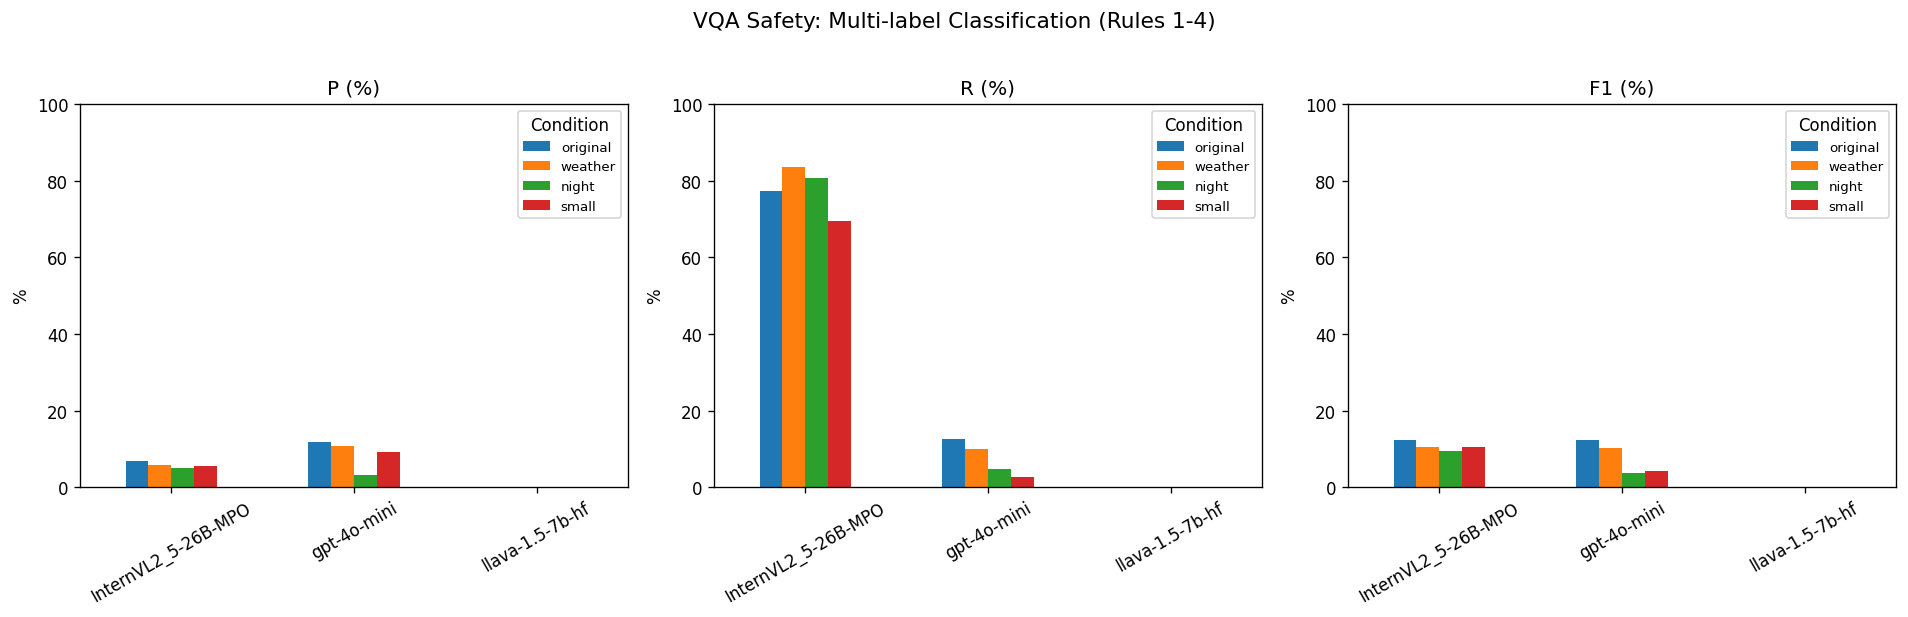

In [23]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

models = df['model'].unique()
n_models = len(models)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, metric in enumerate(['overall_P', 'overall_R', 'overall_F1']):
    ax = axes[idx]
    pivot = df.pivot_table(index='model', columns='condition', values=metric, aggfunc='first')
    pivot = pivot.reindex(columns=[c for c in CONDITIONS if c in pivot.columns])
    (pivot * 100).plot(kind='bar', ax=ax, rot=30)
    ax.set_title(metric.replace('overall_', '').upper() + ' (%)')
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.legend(title='Condition', fontsize=8)
    ax.set_ylim(0, 100)

plt.suptitle('VQA Safety: Multi-label Classification (Rules 1-4)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(str(BENCHMARK_ROOT / 'notebooks' / 'vqa_safety_classification.png'), bbox_inches='tight')
plt.show()

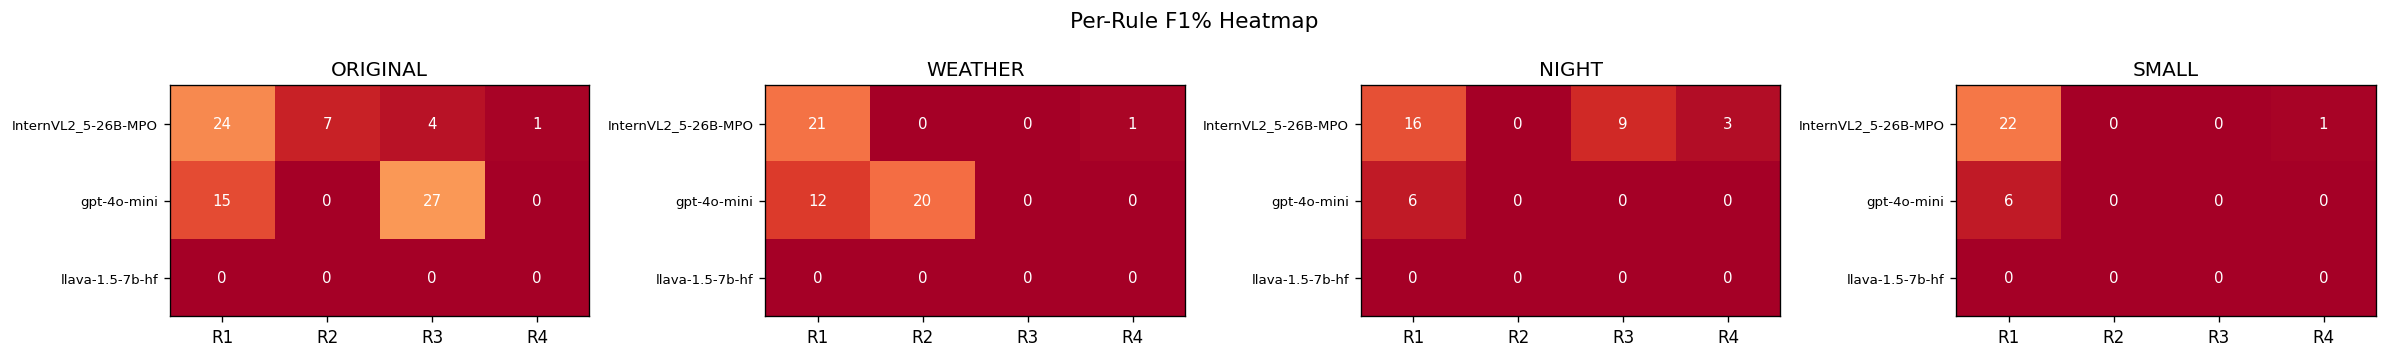

In [24]:
# Per-rule F1 heatmap
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(5 * len(CONDITIONS), max(3, n_models * 0.6 + 1)))
if len(CONDITIONS) == 1:
    axes = [axes]

for i, cond in enumerate(CONDITIONS):
    ax = axes[i]
    cond_df = df[df['condition'] == cond].set_index('model')
    if cond_df.empty:
        ax.set_title(f'{cond} (no data)')
        continue
    
    rule_f1 = cond_df[[f'rule{r}_F1' for r in RULES]] * 100
    rule_f1.columns = [f'Rule {r}' for r in RULES]
    
    im = ax.imshow(rule_f1.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'R{r}' for r in RULES])
    ax.set_yticks(range(len(cond_df)))
    ax.set_yticklabels(cond_df.index, fontsize=8)
    ax.set_title(f'{cond.upper()}')
    
    for y in range(len(cond_df)):
        for x in range(4):
            val = rule_f1.values[y, x]
            ax.text(x, y, f'{val:.0f}', ha='center', va='center', fontsize=9,
                   color='white' if val < 30 or val > 70 else 'black')

plt.suptitle('Per-Rule F1% Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig(str(BENCHMARK_ROOT / 'notebooks' / 'vqa_safety_per_rule_heatmap.png'), bbox_inches='tight')
plt.show()

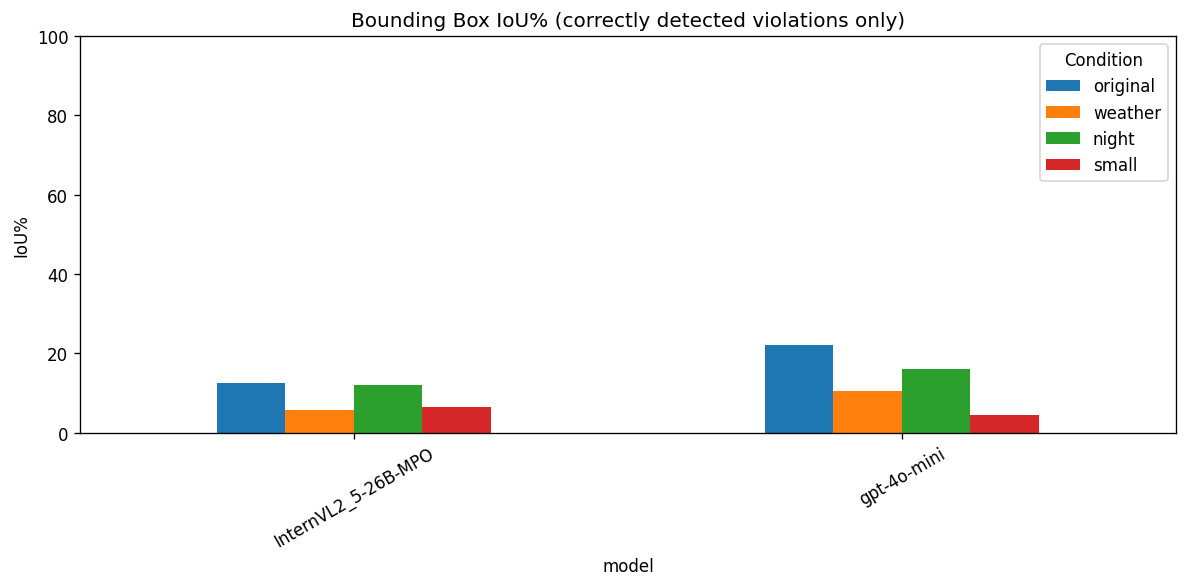

In [25]:
# IoU comparison (only for models with bbox predictions)
iou_data = df[df['overall_IoU'].notna()].copy()
if not iou_data.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    pivot_iou = iou_data.pivot_table(index='model', columns='condition', values='overall_IoU', aggfunc='first')
    pivot_iou = pivot_iou.reindex(columns=[c for c in CONDITIONS if c in pivot_iou.columns])
    (pivot_iou * 100).plot(kind='bar', ax=ax, rot=30)
    ax.set_title('Bounding Box IoU% (correctly detected violations only)')
    ax.set_ylabel('IoU%')
    ax.set_ylim(0, 100)
    ax.legend(title='Condition')
    plt.tight_layout()
    plt.savefig(str(BENCHMARK_ROOT / 'notebooks' / 'vqa_safety_bbox_iou.png'), bbox_inches='tight')
    plt.show()
else:
    print("No models have valid bbox IoU scores.")

## 8b. Radar Charts — Model Strengths & Weaknesses

In [ ]:
from math import pi

# --- F1 Radar: normalize by global best (single max across all models & conditions) ---
pivot_f1 = df.pivot_table(index='model', columns='condition', values='overall_F1', aggfunc='first')
pivot_f1 = pivot_f1.reindex(columns=CONDITIONS) * 100  # to percentage

# Single global max: best F1 across all models and conditions
global_max = pivot_f1.values.max()
if global_max == 0:
    global_max = 1
pivot_norm = pivot_f1 / global_max * 100

# Radar setup
labels = [c.upper() for c in CONDITIONS]
n_axes = len(labels)
angles = np.linspace(0, 2 * pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

model_colors = plt.cm.tab10(np.linspace(0, 1, len(pivot_f1)))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for mi, (model, row) in enumerate(pivot_f1.iterrows()):
    raw_vals = row.values.tolist()
    norm_vals = pivot_norm.loc[model].values.tolist()
    norm_vals += norm_vals[:1]
    raw_vals += raw_vals[:1]
    
    color = model_colors[mi]
    ax.plot(angles, norm_vals, 'o-', linewidth=2.2, label=model, color=color, markersize=6)
    ax.fill(angles, norm_vals, alpha=0.08, color=color)
    
    # Annotate raw F1 values at each vertex
    for j in range(n_axes):
        offset = 8 if mi % 2 == 0 else -8
        ax.annotate(f'{raw_vals[j]:.1f}',
                    xy=(angles[j], norm_vals[j]),
                    fontsize=8, fontweight='bold', color=color,
                    textcoords='offset points', xytext=(0, offset),
                    ha='center', va='center')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='gray')
ax.set_title(f'Overall F1% by Condition\n(normalized by global best = {global_max:.1f}%, labels = raw F1%)',
             fontsize=13, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(str(BENCHMARK_ROOT / 'notebooks' / 'vqa_safety_f1_radar.png'), bbox_inches='tight')
plt.show()

## 9. Export Results

In [29]:
# Save to CSV
export_cols = ['model', 'condition', 'n_valid', 'n_errors']
for r in RULES:
    export_cols += [f'rule{r}_P', f'rule{r}_R', f'rule{r}_F1', f'rule{r}_IoU']
export_cols += ['overall_P', 'overall_R', 'overall_F1', 'overall_IoU']

out_path = BENCHMARK_ROOT / 'notebooks' / 'vqa_safety_results.csv'
df[export_cols].to_csv(out_path, index=False, float_format='%.4f')
print(f"Saved to {out_path}")

Saved to /users/PGS0407/binben14/VietHuy/Benchmark_runner/notebooks/vqa_safety_results.csv
